In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from PIL import Image
import pathlib
import copy

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [10]:
import numpy as np
from PIL import Image
import pathlib

size = 300

def load_image(file, size):
    img = Image.open(file).convert("RGB")   # <--- force 3 channels
    img = img.resize((size, size))
    return np.array(img)                    # shape: (300, 300, 3)

def load_labelled_images(path, size):
    labels = []
    files = []
    
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        for file_info in pathlib.Path(path).glob("**/" + ext):
            # probably want the folder name as label, not file name:
            # labels.append(file_info.parts[-2])
            labels.append(file_info.parts[-2])  # if you really want filename as label
            files.append(str(file_info))
    
    imgs_list = [load_image(f, size) for f in files]
    imgs = np.stack(imgs_list, axis=0)      # (N, 300, 300, 3)
    return imgs, np.array(labels)

images, labels = load_labelled_images("../Scaling_dataset", size)
print("Loaded", len(images), "images in the following", len(np.unique(labels)), "classes:")
for label in np.unique(labels):
    print(" ", label)


Loaded 41 images in the following 2 classes:
  Compliant
  Not Compliant


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import copy
import matplotlib.pyplot as plt

# --- 1. DATA PREPARATION ---
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

train_idx, val_idx = train_test_split(
    np.arange(len(images)), 
    test_size=0.2, 
    stratify=labels_encoded, 
    random_state=42
)

# --- 2. DATASET CLASS & AUGMENTATION ---
class ComplianceDataset(Dataset):
    def __init__(self, imgs, lbls, transform=None):
        self.imgs = imgs
        self.lbls = lbls
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        # Convert NumPy array (H,W,3) to PIL Image for torchvision transforms
        img = Image.fromarray(self.imgs[idx])
        lbl = self.lbls[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, lbl

# MobileNetV2 expects 224x224 and specific normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = ComplianceDataset(images[train_idx], labels_encoded[train_idx], transform=data_transforms['train'])
val_dataset = ComplianceDataset(images[val_idx], labels_encoded[val_idx], transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
# --- 3. THE MODEL (TRANSFER LEARNING) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# MobileNetV3-Large structure:
# features output: 960 channels
# classifier: Linear(960, 1280) → Hardswish → Dropout → Linear(1280, 1000)
# We need to replace the LAST linear layer (1280 -> 1000) with (1280 -> 1)

# Option 1: Replace just the last layer (recommended)
num_ftrs = model.classifier[3].in_features  # Should be 1280
model.classifier[3] = nn.Linear(num_ftrs, 1)  # Replace last layer
# Keep the Hardswish and Dropout that come before it

# Then wrap in sigmoid for binary classification
model = nn.Sequential(model, nn.Sigmoid())

model = model.to(device)

# Verify the structure
print("Model classifier structure:")
print(model[0].classifier)
print(f"Input to classifier[3]: {model[0].classifier[3].in_features}")
print(f"Output from classifier[3]: {model[0].classifier[3].out_features}")

# --- 4. TRAINING SETUP ---
criterion = nn.BCELoss()
# Optimize ONLY the last linear layer parameters
optimizer = optim.Adam(model[0].classifier[3].parameters(), lr=1e-4)

# --- 5. THE LOOP ---
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            curr_loader = train_loader
        else:
            model.eval()
            curr_loader = val_loader

        running_loss = 0.0
        running_corrects = 0

        for inputs, lbls in curr_loader:
            inputs = inputs.to(device)
            lbls = lbls.to(device).float().view(-1, 1)

            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                # Model is now wrapped in Sequential, so we call it directly
                outputs = model(inputs)
                loss = criterion(outputs, lbls)
                preds = (outputs > 0.5).float()

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == lbls.data)

        epoch_loss = running_loss / len(curr_loader.dataset)
        epoch_acc = running_corrects.double() / len(curr_loader.dataset)

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {history["train_loss"][-1]:.4f} Val Loss: {history["val_loss"][-1]:.4f} Val Acc: {history["val_acc"][-1]:.4f} Train Acc: {history["train_acc"][-1]:.4f}')



Model classifier structure:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1, bias=True)
)
Input to classifier[3]: 1280
Output from classifier[3]: 1
Epoch 5/30 | Train Loss: 0.6779 Val Loss: 0.6526 Val Acc: 0.6667 Train Acc: 0.6562
Epoch 10/30 | Train Loss: 0.6463 Val Loss: 0.6459 Val Acc: 0.7778 Train Acc: 0.7188
Epoch 15/30 | Train Loss: 0.6142 Val Loss: 0.6381 Val Acc: 0.7778 Train Acc: 0.9062
Epoch 20/30 | Train Loss: 0.5493 Val Loss: 0.6249 Val Acc: 0.8889 Train Acc: 0.9062
Epoch 25/30 | Train Loss: 0.6106 Val Loss: 0.6089 Val Acc: 0.8889 Train Acc: 0.8438
Epoch 30/30 | Train Loss: 0.5443 Val Loss: 0.5907 Val Acc: 0.8889 Train Acc: 0.9375


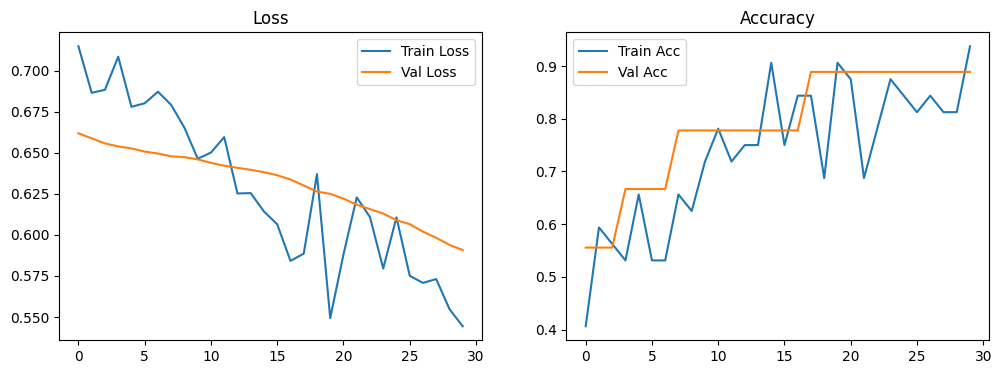

In [15]:

# --- 6. PLOT RESULTS ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend(); plt.title('Accuracy')
plt.show()



--- Classification Report ---
               precision    recall  f1-score   support

    Compliant       0.83      1.00      0.91         5
Not Compliant       1.00      0.75      0.86         4

     accuracy                           0.89         9
    macro avg       0.92      0.88      0.88         9
 weighted avg       0.91      0.89      0.89         9



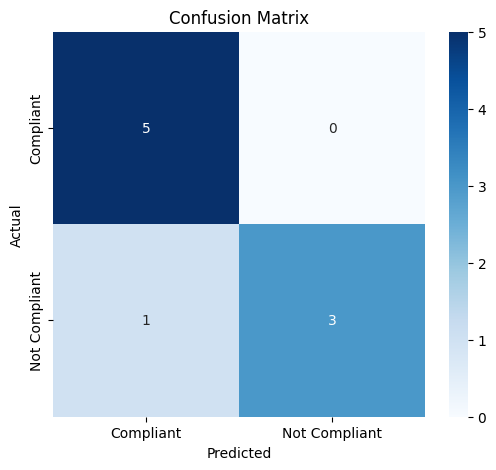

In [16]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set the model to evaluation mode
model.eval()

all_preds = []
all_labels = []

# 2. Collect predictions from the data loader (e.g., val_loader or test_loader)
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        
        # Get model outputs
        outputs = model(inputs)
        
        # Since using Sigmoid, convert probabilities to binary (0 or 1)
        preds = (outputs > 0.5).int().cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# 3. Print the Classification Report
# 'le.classes_' provides the names: ['Compliant', 'Not Compliant']
target_names = le.classes_ 
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

# 4. (Optional) Generate the Confusion Matrix seen in your second image
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [17]:
import os

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "../Checkpoints/mobilenet-23-01.pth")